## License

This notebook is a conversion of a Sentinel Hub evalscript and is licensed under
**CC-BY-SA-4.0**.

Original evalscript: https://custom-scripts.sentinel-hub.com/custom-scripts/sentinel-2/ndsi/  
Source: Sentinel Hub Custom Scripts (CC-BY-SA-4.0)  
Conversion: Development Seed (openEO-UDP project)  

# Normalised Difference Snow Index, NDSI and openEO 

This notebook demonstrates how to detect snow using NDSI:

\begin{equation*}
{NDSI} = \frac{B03 - B11}{B03 + B11}
\end{equation*}

Where: 
- B03 (559.8 nm): Green
- B11 (1613.7 nm): SWIR

The Sentinel-2 NDSI takes advantage of the different reflectance properties of snow in the visible and short-wave infrared (SWIR) regions. Snow is highly reflective in the visible bands (such as green, B03) but strongly absorbs SWIR. This allows its differentiation from clouds who remain bright in both visible and SWIR bands.

## Overview

In this notebook, we will:
1. Connect to an OpenEO backend service
2. Define an area of interest containing terrestrial land
3. Load Sentinel-2-L2A imagery for a specific date
4. Compute the NDSI and apply a threshold (NDSI > 0.42) to classify snow, which will be rendered blue


## Import Required Libraries

We begin by importing the necessary Python libraries for data processing and visualization.

In [32]:
import openeo
import shapely
import rioxarray
import numpy as np
import matplotlib.pyplot as plt
from openeo.processes import array_create, if_

## Connect to OpenEO Backend

Connect to CDSE OpenEO backend and authenticate using OpenID Connect.

In [33]:
connection = openeo.connect(
    url="https://openeo.dataspace.copernicus.eu/"
).authenticate_oidc()

Authenticated using refresh token.


## Define Area of Interest

Define the spatial extent for our analysis. This example uses coordinates of Haka Conservation Park area in New Zealand.

In [34]:
spatial_extent = {"west": 168.273, "south": -45.589, "east": 169.097, "north": -45.121}

## Load Sentinel-2 Data

Load Sentinel-2 L2A (bottom-of-atmosphere reflectance) data. We need multiple bands for NDSI calculation and color composite:

- **B02**: Blue, for true-color composite
- **B03**: Green, for NDSI calculation with B11 and for true-color composite
- **B04**: Red, for true-color composite
- **B11**: SWIR, for NDSI calculation

In [35]:
s2cube = connection.load_collection(
    "SENTINEL2_L2A",
    spatial_extent=spatial_extent,
    temporal_extent=["2019-09-19", "2019-09-21"], # 
    bands=[
        "B02",
        "B03",
        "B04",
        "B11",
    ],
)

# Avoid extra data outside the spatial extent
s2cube = s2cube.mask_polygon(
    shapely.geometry.box(
        minx=spatial_extent["west"],
        miny=spatial_extent["south"],
        maxx=spatial_extent["east"],
        maxy=spatial_extent["north"],
    )
)

# Take the first instance of the time dimension
s2cube = s2cube.reduce_dimension(dimension="t", reducer="first")

## Calculate NDSI and define the color map

In [36]:
def snow_viz(data):
    B02, B03, B04, B11 = (
        data[0],
        data[1],
        data[2],
        data[3]
    )

    # Scale to reflectance
    B02 = B02 / 10000
    B03 = B03 / 10000
    B04 = B04 / 10000
    B11 = B11 / 10000

    NDSI = (B03 - B11) / (B03 + B11)

    snow_mask = NDSI > 0.42

    red = if_(
        snow_mask,
        0,
        2.5 * B04
    )

    green = if_(
        snow_mask,
        0.8,
        2.5 * B03
    )

    blue = if_(
        snow_mask, 
        1,
        2.5 * B02
    )

    return array_create([red, green, blue])
    

In [37]:
snow_image = s2cube.apply_dimension(
    dimension="bands",
    process=snow_viz
)

snow_image = snow_image.linear_scale_range(input_min=0, input_max=1, output_min=0, output_max=255)

snow_image = snow_image.save_result("GTiff")

In [38]:
snow_image.download("ndsi_snow_classifier.tif")

## Visualize the Result

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0..65535].


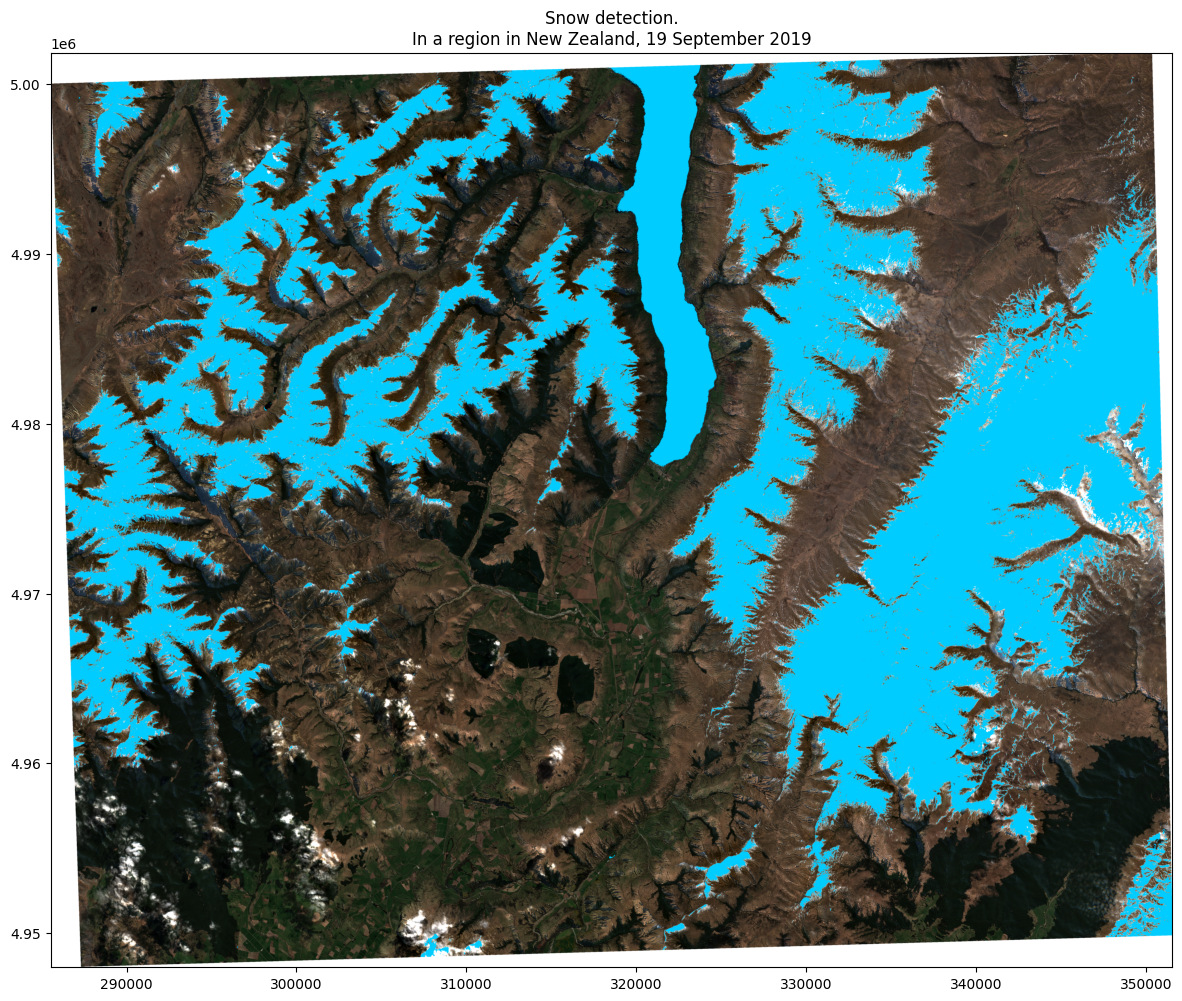

In [39]:
ds = rioxarray.open_rasterio("ndsi_snow_classifier.tif")

rgb = np.stack([
    ds.sel(band=1).values,
    ds.sel(band=2).values,
    ds.sel(band=3).values
], axis=-1)

fig, ax = plt.subplots(figsize=(12, 10))
ax.imshow(rgb, extent=[ds.x.values.min(), ds.x.values.max(), ds.y.values.min(), ds.y.values.max()])
plt.title(
    "Snow detection.\n"
    "In a region in New Zealand, 19 September 2019"
)
plt.tight_layout()
plt.show()

## Attribution

This openEO User-Defined Process is a conversion of the original Sentinel Hub evalscript:

**Original Script:** [Normalised Difference Snow Index, NDSI](https://custom-scripts.sentinel-hub.com/custom-scripts/sentinel-2/ndsi/)

**Author:** (Author is not listed in the original script)

**Source Repository:** [Sentinel Hub Custom Scripts](https://github.com/sentinel-hub/custom-scripts)

This conversion maintains the scientific methodology and visualization approach of the original evalscript while adapting it to the openEO process graph framework for interoperability across openEO-compliant backends.